# Optimization approach for Controller Parameters

Optimizing the behavior of a continuous representation being able to substitute the original discrete logic.

In [150]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Imports and Definitions

In [151]:
import os

import diffpssi.grid_library.ibb_model as mdl
import numpy as np
import torch

from diffpssi.optimization_lib.ps_optimization import PowerSystemOptimization
from diffpssi.power_sim_lib.simulator import PowerSystemSimulation as Pss
from diffpssi.power_sim_lib import TestBench
from diffpssi.power_sim_lib.models.voltage_controller import (
    OLTC_Discrete,
    OLTC_Continuous,
    OLTC_Continuous_Milano,
    OLTC_Continuous_PI,
    FSM_Only_Discrete,
)

np.random.seed(0)

In [152]:
def jump_input(t, a: float = 1, b: float = 1.3, threshold: float = 1):
    """Callable jump input function.
    Args:
        t (float or list): time instant(s)
        a (float, optional): value before threshold. Defaults to 1.
        b (float, optional): value after threshold. Defaults to 1.1.
        threshold (float, optional): time threshold. Defaults to 1.
    Returns:
        torch.tensor or list: jump value(s)
    """
    # Depending on input type, return single or list of jump values
    # Necessary for compatibility with Recorder class and simulator
    if isinstance(t, float):
        if t < threshold:
            jump = a * torch.ones((1, 1), dtype=torch.float64)
        else:
            jump = b * torch.ones((1, 1), dtype=torch.float64)
    else:  # isinstance(t, list):
        jump = []
        for i in t:
            if i < threshold:
                jump.append(a * torch.ones((1, 1), dtype=torch.float64))
            else:
                jump.append(b * torch.ones((1, 1), dtype=torch.float64))
        jump = torch.tensor(jump, dtype=torch.float64)
    return jump

In [153]:
def duplet_input(t, a: float = 1, b: float = 0.3, t1: float = 1, t2: float = 5, td: float = 2):
    """Callable jump input function.
    Args:
        t (float or list): time instant(s)
        a (float, optional): value before threshold. Defaults to 1.
        b (float, optional): additional value after threshold. Defaults to 0.3.
        t1 (float, optional): start time threshold 1. Defaults to 1.
        t2 (float, optional): start time threshold 2. Defaults to 5.
        td (float, optional): duration between jumps. Defaults to 2.

    Returns:
        torch.tensor or list: jump value(s)
    """
    # Depending on input type, return single or list of jump values
    # Necessary for compatibility with Recorder class and simulator
    if isinstance(t, float):
        if t > t1 and t < t1 + td:
            jump = (a + b) * torch.ones((1, 1), dtype=torch.float64)
        elif t > t2 and t < t2 + td:
            jump = (a - b) * torch.ones((1, 1), dtype=torch.float64)
        else:
            jump = a * torch.ones((1, 1), dtype=torch.float64)
    else:  # isinstance(t, list):
        jump = []
        for i in t:
            if i > t1 and i < t1 + td:
                jump.append((a + b) * torch.ones((1, 1), dtype=torch.float64))
            elif i > t2 and i < t2 + td:
                jump.append((a - b) * torch.ones((1, 1), dtype=torch.float64))
            else:
                jump.append(a * torch.ones((1, 1), dtype=torch.float64))
        jump = torch.tensor(jump, dtype=torch.float64)
    return jump

In [154]:
def input_function(t, a: float = 0.1, b: float = 1.1):
    """Input function for the test bench simulation, respectively control block testing.

    Args:
        t (float or list): time instant(s)
        a (float, optional): exponential decay rate. Defaults to 0.1.
        b (float, optional): final value after decay. Defaults to 1.1.
    
    Returns:
        torch.tensor or list: input value(s)
    """
    # Depending on input type, return single or list of jump values
    # Necessary for compatibility with Recorder class and simulator
    if isinstance(t, float):
        a = torch.tensor(a, dtype=torch.float64)
        b = torch.tensor(b, dtype=torch.float64)
        input = (
            b - (b - 1) * torch.exp(-a * t) 
            # * torch.ones((1, 1), dtype=torch.float64)
        )
    else:
        a = torch.tensor(a, dtype=torch.float64)
        b = torch.tensor(b, dtype=torch.float64)
        input = []
        for i in t:
            input.append(
                b - (b - 1) 
                * torch.exp(-a * i)
                # * torch.ones((1, 1), dtype=torch.float64)
            )
        
        input = torch.tensor(input, dtype=torch.float64)

    
    return input

In [155]:
input_function(t=1.0)

tensor(1.0095, dtype=torch.float64)

## Define Simulation and Re-Initiate Necessary Tensors 

In [156]:
analysis_models = [
    # [OLTC_Discrete(param_dict={
    #     "t_1": 5,
    #     "pt_1": 0,
    #     "db": 0.05,
    #     "time_sensitive": True,
    #     }), 1],
    [FSM_Only_Discrete(param_dict={
        "t_1": 0.02,
        "db": 0.025,
        "delta_m": 0.04,
        "m_min": 0.84,
        "m_max": 1.20,
        "gamma": 3,
        }), 1],
    # [OLTC_Continuous(param_dict={
    #     "t_1": 10,
    #     "gain_pt1": 1,
    #     # "db": 0,
    #     "m_min": 0.9,
    #     "m_max": 1.1,
    #     "v_ref": 1.0
    #     }), 1],
    [OLTC_Continuous_Milano(param_dict={
        "kd": 0.001,
        "ki": 0.003,
        # "db": 0,
        "m_min": 0.84,
        "m_max": 1.20,
        "v_ref": 1.0
        }), 1],
    # [OLTC_Continuous_PI(param_dict={
    #     "kp": 0.01,
    #     "ki": 0.07,
    #     # "db": 0,
    #     "lim": 0.1,
    #     "v_ref": 1.0
    #     }), 1],
]


def record_dict(simulation, call=False):
    record_dict = {
        "Discrete OLTC model": simulation.diff_models[0].u_l,
        # "Continuous OLTC model":    simulation.diff_models[1].u_l,
        # "Continuous OLTC Milano model": simulation.diff_models[0].u_l,
        # "Continuous OLTC PI model": simulation.diff_models[3].u_l,,
    }
    if call:
        return record_dict.values()
    else:
        return record_dict

In [157]:
parallel_sims = 10

v_ref = 0.7

input_mock = lambda t: jump_input(t, b=v_ref)

tb = TestBench(
    time_step=0.005,
    sim_time=10,
    inspection_models=analysis_models,
    # input_func=input_function,
    input_func=input_mock,
    # input_func=duplet_input,
    record_func=record_dict,
    default_runner="run_oltc_control",
    parallel_sims=parallel_sims,
)

tb.diff_models[0].dir = -1

## Generate Original Comparision Data

In [158]:
t, benchmark_result = tb.run_oltc_control()

100%|██████████| 2002/2002 [00:00<00:00, 4076.10it/s]

Dynamic simulation finished in 0.49 seconds


In [159]:
benchmark_transformed = (
    benchmark_result[0, :, 0:1] 
    * torch.ones((parallel_sims,1,1),
    requires_grad=True)
).reshape(parallel_sims, -1, 1)

benchmark_transformed = benchmark_transformed.detach().clone()

In [160]:
tb.diff_models.pop(0)

## Construct and Run Optimization

In [161]:
# For model Milano
tb.diff_models[0].lag.kd = torch.tensor(
    np.random.uniform(0.01, 0.5, (parallel_sims, 1)),
    requires_grad=True,
    dtype=torch.complex128,
)
tb.diff_models[0].lag.ki = torch.tensor(
    np.random.uniform(0.01, 0.5, (parallel_sims, 1)),
    requires_grad=True,
    dtype=torch.complex128,
)

optimizable_parameters = [
    tb.diff_models[0].lag.kd,
    tb.diff_models[0].lag.ki,
]

param_names = [
    "Controller k_d",  # Geändert: korrekter Name
    "Controller k_i",  # Geändert: korrekter Name
]

params_original = [
    0.21,  # Original k_d Wert
    0.37,   # Original k_i Wert
]

# # For custom PI model
# tb.diff_models[0].pi.k_p = torch.tensor(
#     np.random.uniform(0, 0.2, (parallel_sims, 1)),
#     requires_grad=True,
#     dtype=torch.float64,
# )
# tb.diff_models[0].pi.k_i = torch.tensor(
#     np.random.uniform(0, 0.1, (parallel_sims, 1)),
#     requires_grad=True,
#     dtype=torch.float64,
# )

# optimizable_parameters = [
#     tb.diff_models[0].pi.k_p,
#     tb.diff_models[0].pi.k_i,
# ]

# param_names = [
#     "Controller k_p",  # Geändert: korrekter Name
#     "Controller k_i",  # Geändert: korrekter Name
# ]

# params_original = [
#     0.025,  # Original k_p Wert
#     0.025,  # Original k_i Wert
# ]

# # For custom PT1 model
# # Initialisiere t_pt1X in einem sinnvollen Bereich (1 bis 30)
# tb.diff_models[0].pt1.t_pt1 = torch.tensor(
#     np.random.uniform(45, 55, (parallel_sims, 1)),  # Geändert: min von 0 auf 1
#     requires_grad=True,
#     dtype=torch.float64,
# )
# # Initialisiere gain_pt1 in einem sinnvollen Bereich (0.9 bis 1)
# tb.diff_models[0].pt1.gain_pt1 = torch.tensor(
#     np.random.uniform(0.9, 1, (parallel_sims, 1)),  # Geändert: min von 0 auf 0.1, max auf 2
#     requires_grad=True,
#     dtype=torch.float64,
# )
# # tb.diff_models[0].pt1.dir = torch.tensor(
# #     tb.diff_models[0].dir.detach().numpy(),
# #     requires_grad=True,
# #     dtype=torch.float64,
# # )

# optimizable_parameters = [
#     tb.diff_models[0].pt1.t_pt1,
#     tb.diff_models[0].pt1.gain_pt1,
# ]

# param_names = [
#     "Controller t_pt1",  # Geändert: korrekter Name
#     "Controller gain_pt1",  # Geändert: korrekter Name
# ]

# params_original = [
#     50.0,  # Original t_pt1 Wert
#     1.0,   # Original gain_pt1 Wert
# ]

## Gradient based

In [162]:
def mse_loss_function(sim_result, target_data):
    """MSE loss function between simulation result and target data.

    Args:
        sim_result: Simulation result tensor.
        target_data: Target data tensor.

    Returns:
        torch.tensor: Computed loss value.
    """
    return torch.mean(
        torch.sum(torch.square(target_data - sim_result), dim=2), axis=1,
    )

In [163]:
 # mute sim because it does not generate added value
tb.verbose = False

opt = PowerSystemOptimization(
    sim=tb,
    original_data=benchmark_transformed,
    params_optimizable=optimizable_parameters,
    params_original=params_original,
    param_names=param_names,
    loss_function=None,
    max_step=0.06,
    decay=0.9,
    verbose=True,
    enable_plots=True,
)

Using target data to normalize loss function


  0%|          | 0/10 [00:00<?, ?it/s]

Step: 0, Min. Loss Batch: 1, Min. Loss: 0.20614272008268347
Optimized Parameters: Controller k_d: 0.360, Controller k_i: 0.269
Relative Errors in Percent: Controller k_d: 71.64%, Controller k_i: -27.25%
---------------------------------------------------------------------------------


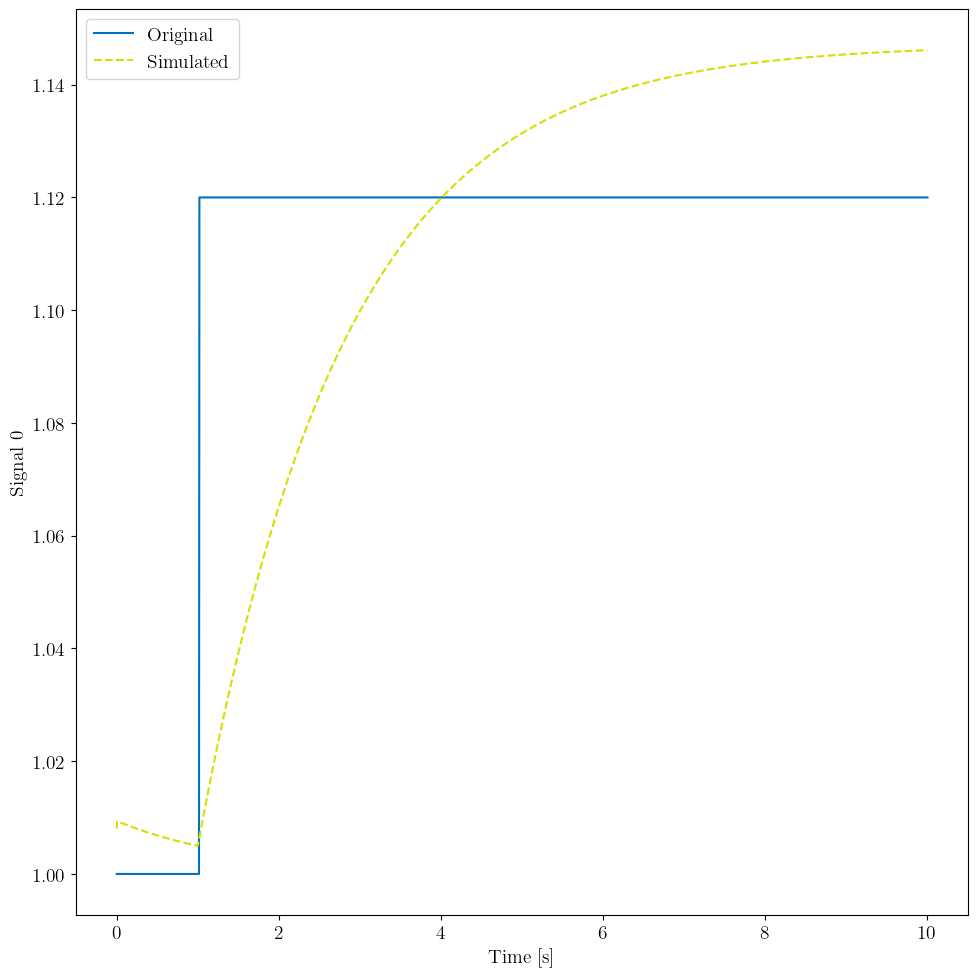

 10%|█         | 1/10 [00:06<00:59,  6.66s/it]

Step: 1, Min. Loss Batch: 1, Min. Loss: 0.17174410528864872
Optimized Parameters: Controller k_d: 0.382, Controller k_i: 0.253
Relative Errors in Percent: Controller k_d: 81.94%, Controller k_i: -31.62%
---------------------------------------------------------------------------------


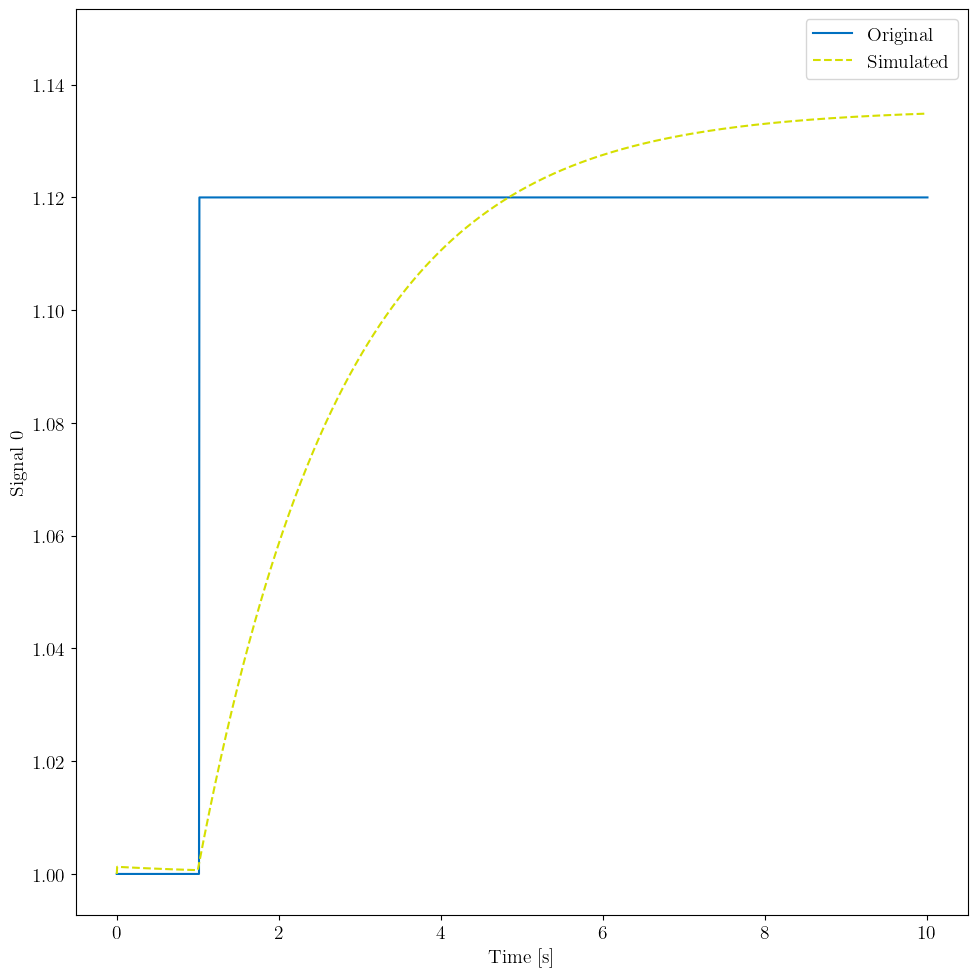

 20%|██        | 2/10 [00:12<00:51,  6.38s/it]

Step: 2, Min. Loss Batch: 8, Min. Loss: 0.14891720591624266
Optimized Parameters: Controller k_d: 0.535, Controller k_i: 0.347
Relative Errors in Percent: Controller k_d: 154.86%, Controller k_i: -6.12%
---------------------------------------------------------------------------------


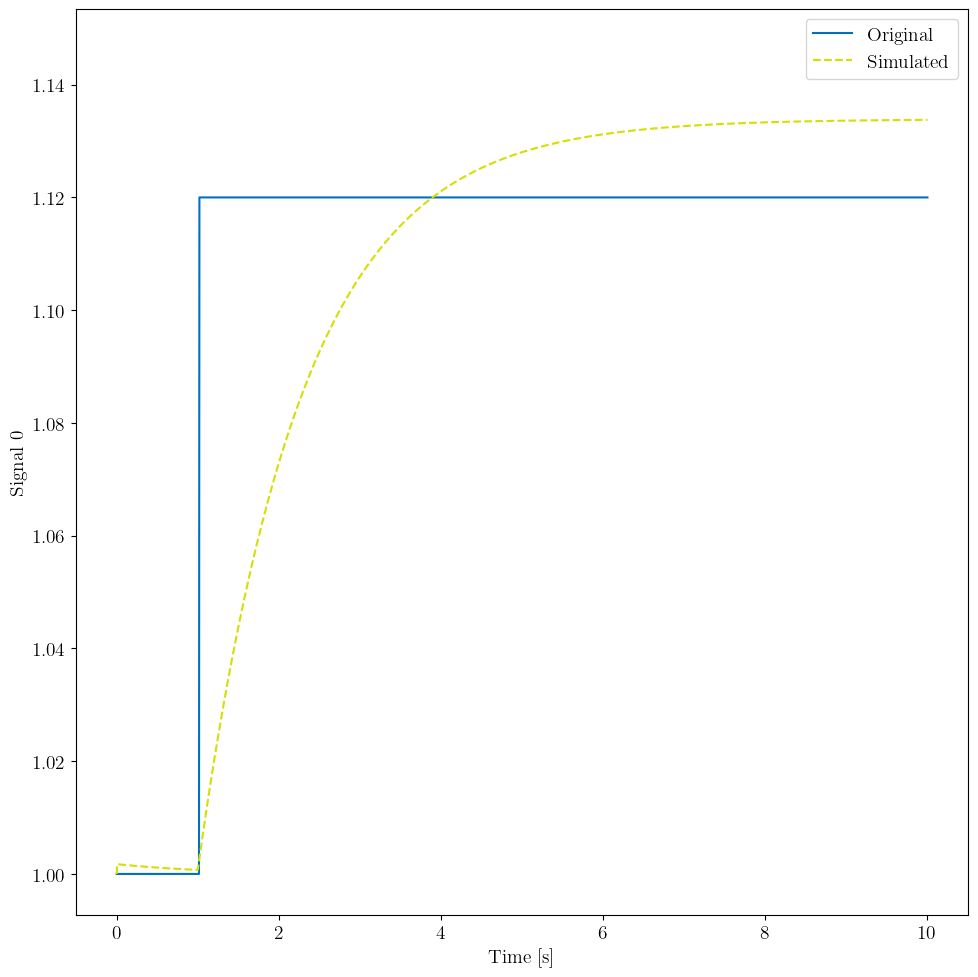

 30%|███       | 3/10 [00:18<00:43,  6.19s/it]

Step: 3, Min. Loss Batch: 8, Min. Loss: 0.12218894157801365
Optimized Parameters: Controller k_d: 0.560, Controller k_i: 0.327
Relative Errors in Percent: Controller k_d: 166.53%, Controller k_i: -11.76%
---------------------------------------------------------------------------------


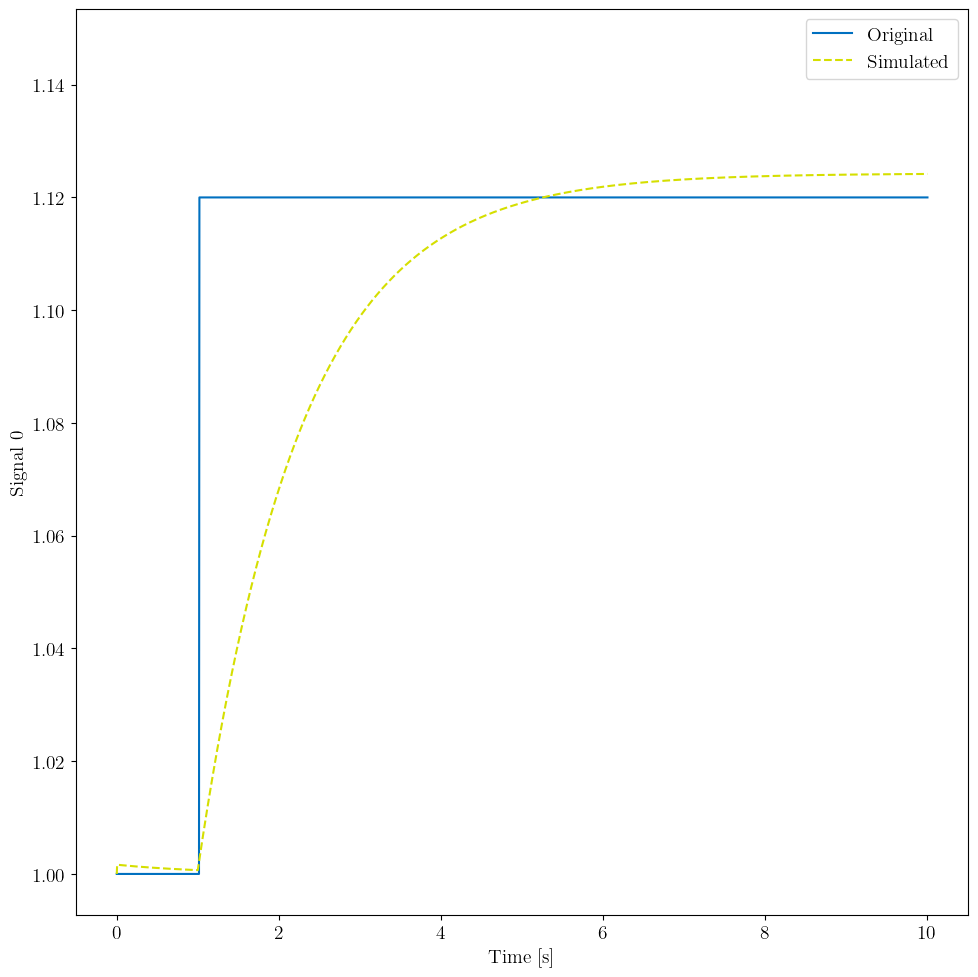

 40%|████      | 4/10 [00:24<00:36,  6.15s/it]

Step: 4, Min. Loss Batch: 7, Min. Loss: 0.13108554979916962
Optimized Parameters: Controller k_d: 0.539, Controller k_i: 0.327
Relative Errors in Percent: Controller k_d: 156.57%, Controller k_i: -11.71%
---------------------------------------------------------------------------------


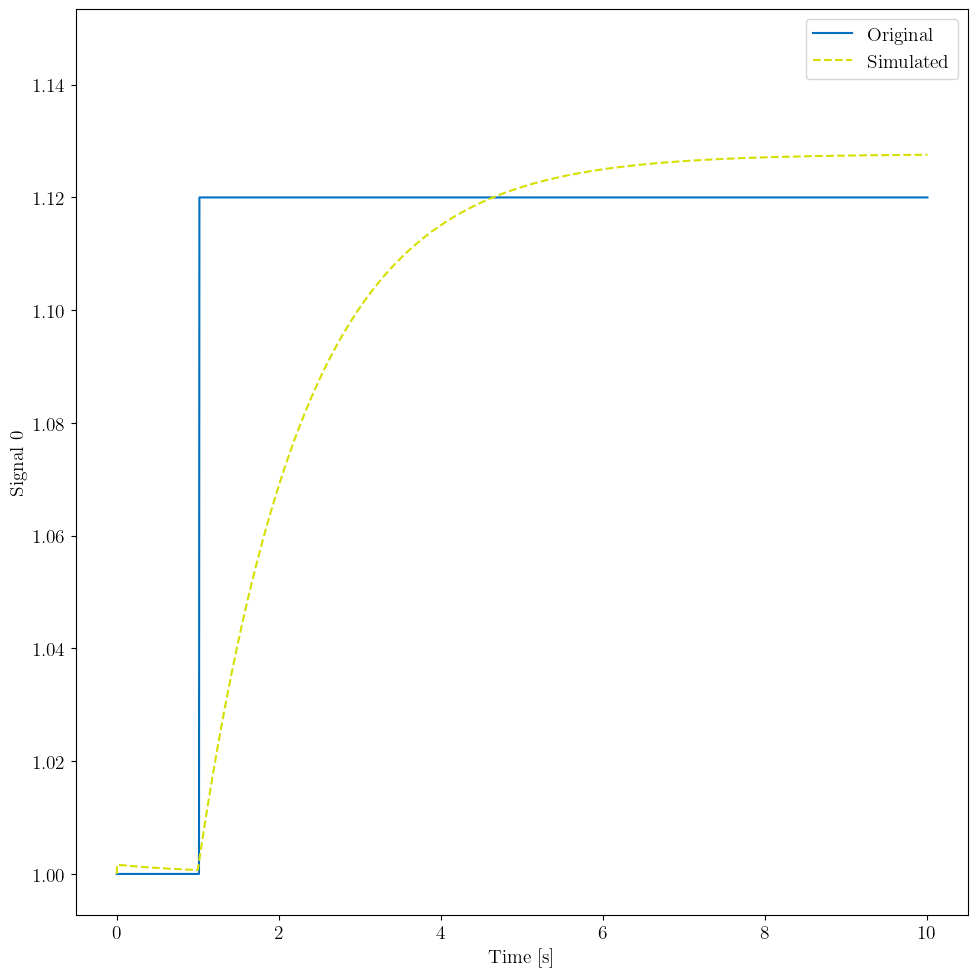

 50%|█████     | 5/10 [00:31<00:30,  6.13s/it]

Decreasing max. step size to 0.054
Step: 5, Min. Loss Batch: 8, Min. Loss: 0.12048543668184433
Optimized Parameters: Controller k_d: 0.565, Controller k_i: 0.325
Relative Errors in Percent: Controller k_d: 168.83%, Controller k_i: -12.07%
---------------------------------------------------------------------------------


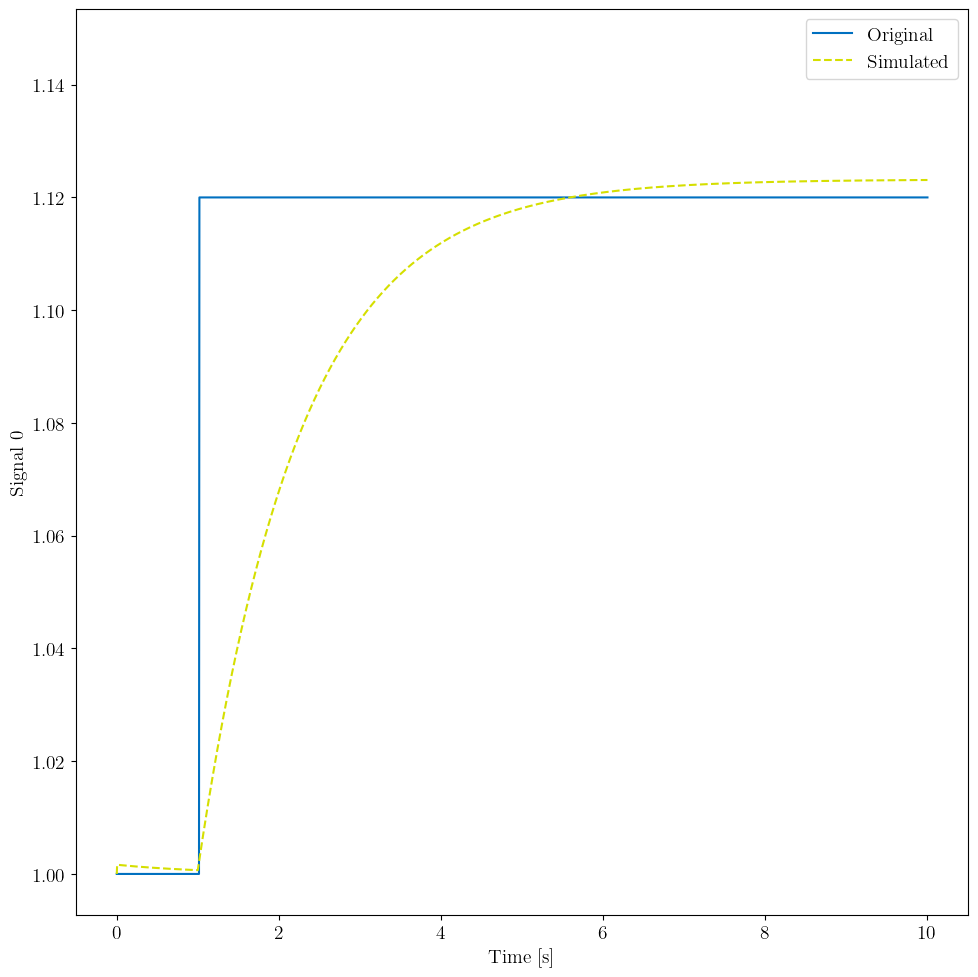

 60%|██████    | 6/10 [00:37<00:24,  6.11s/it]

Step: 6, Min. Loss Batch: 8, Min. Loss: 0.1192425236646243
Optimized Parameters: Controller k_d: 0.572, Controller k_i: 0.324
Relative Errors in Percent: Controller k_d: 172.35%, Controller k_i: -12.50%
---------------------------------------------------------------------------------


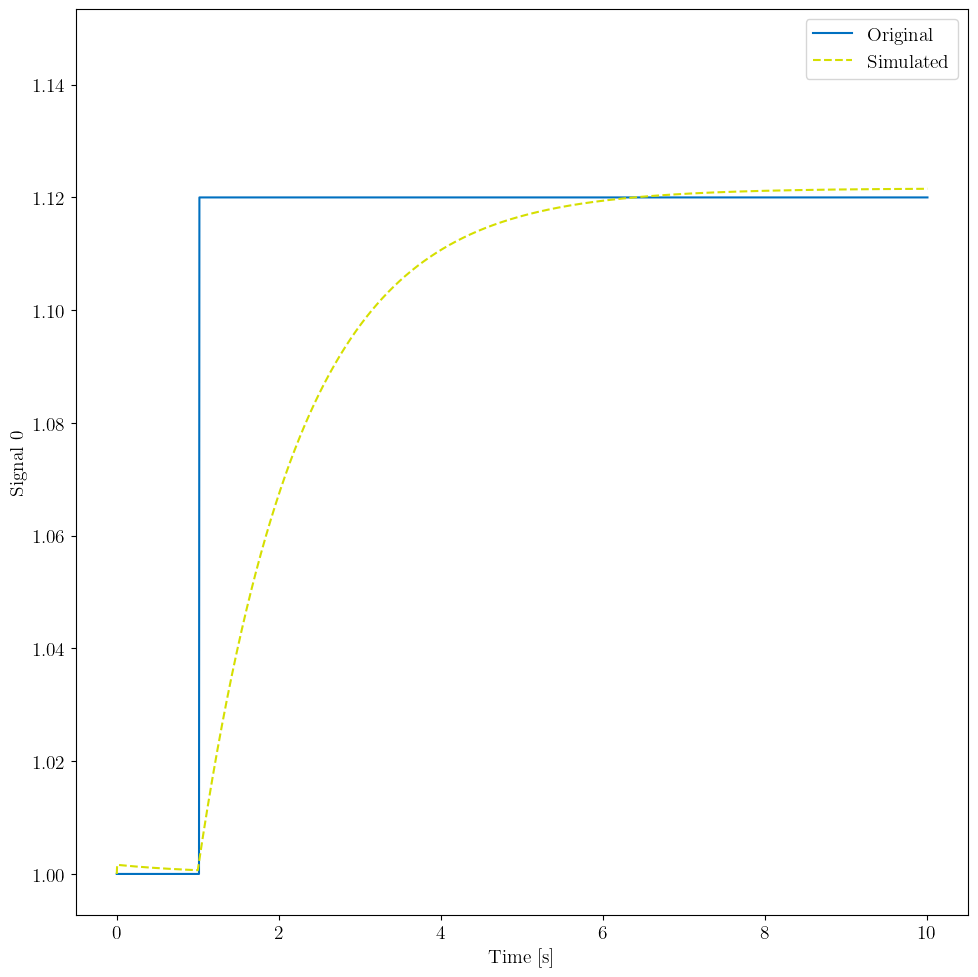

 70%|███████   | 7/10 [00:43<00:18,  6.07s/it]

Step: 7, Min. Loss Batch: 8, Min. Loss: 0.11864703817557043
Optimized Parameters: Controller k_d: 0.575, Controller k_i: 0.325
Relative Errors in Percent: Controller k_d: 173.88%, Controller k_i: -12.03%
---------------------------------------------------------------------------------


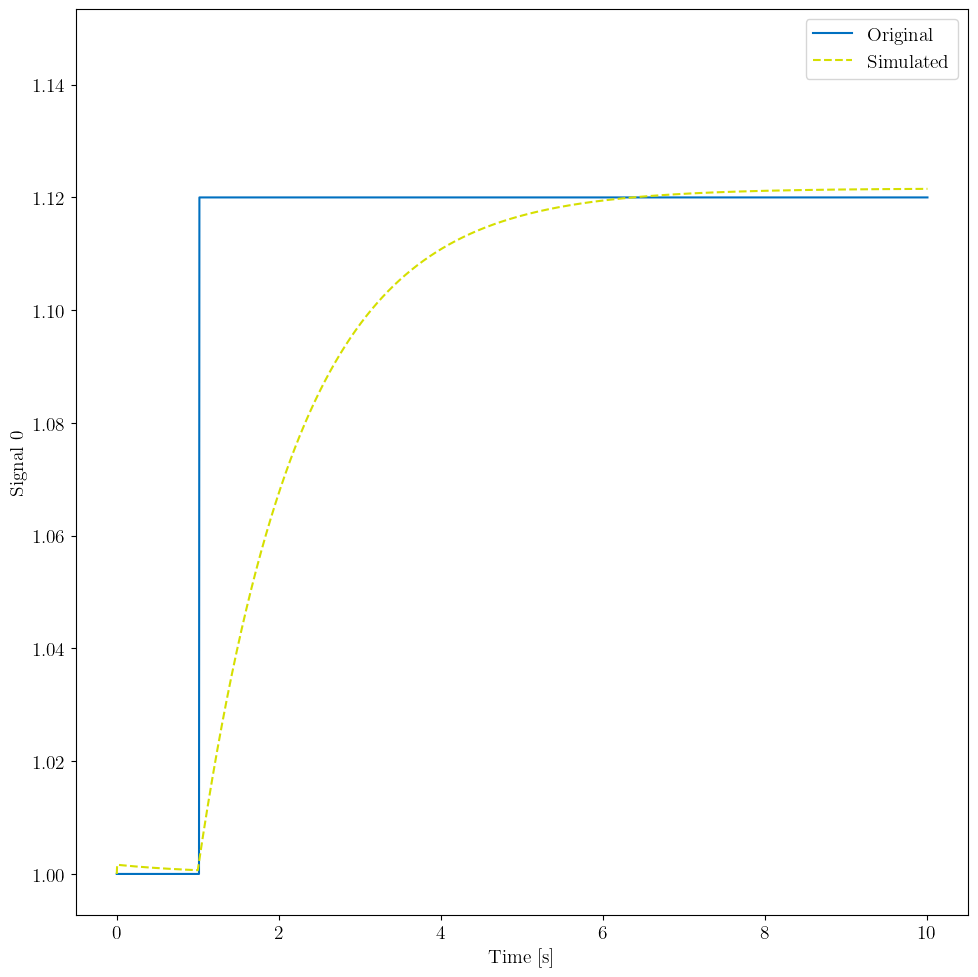

 80%|████████  | 8/10 [00:49<00:12,  6.07s/it]

Step: 8, Min. Loss Batch: 8, Min. Loss: 0.1179959256198308
Optimized Parameters: Controller k_d: 0.582, Controller k_i: 0.327
Relative Errors in Percent: Controller k_d: 177.06%, Controller k_i: -11.56%
---------------------------------------------------------------------------------


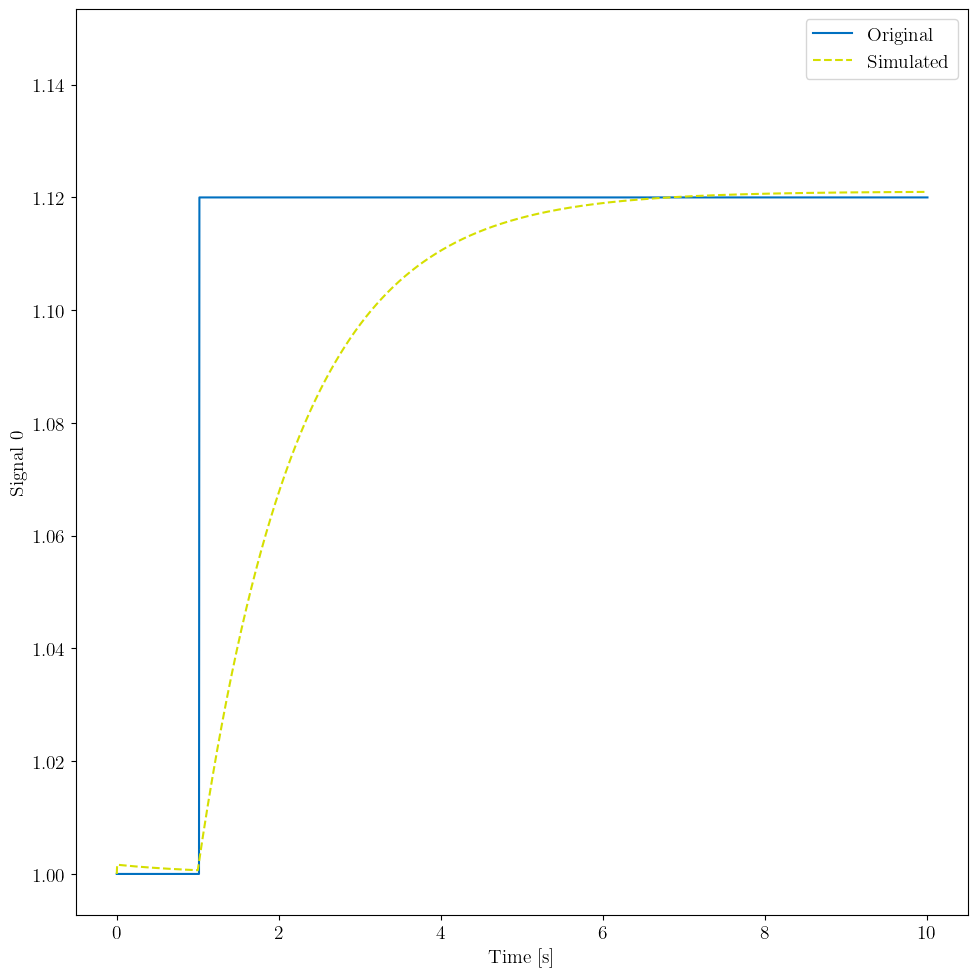

 90%|█████████ | 9/10 [00:55<00:06,  6.18s/it]

Step: 9, Min. Loss Batch: 8, Min. Loss: 0.11272507277014951
Optimized Parameters: Controller k_d: 0.613, Controller k_i: 0.344
Relative Errors in Percent: Controller k_d: 192.02%, Controller k_i: -7.11%
---------------------------------------------------------------------------------


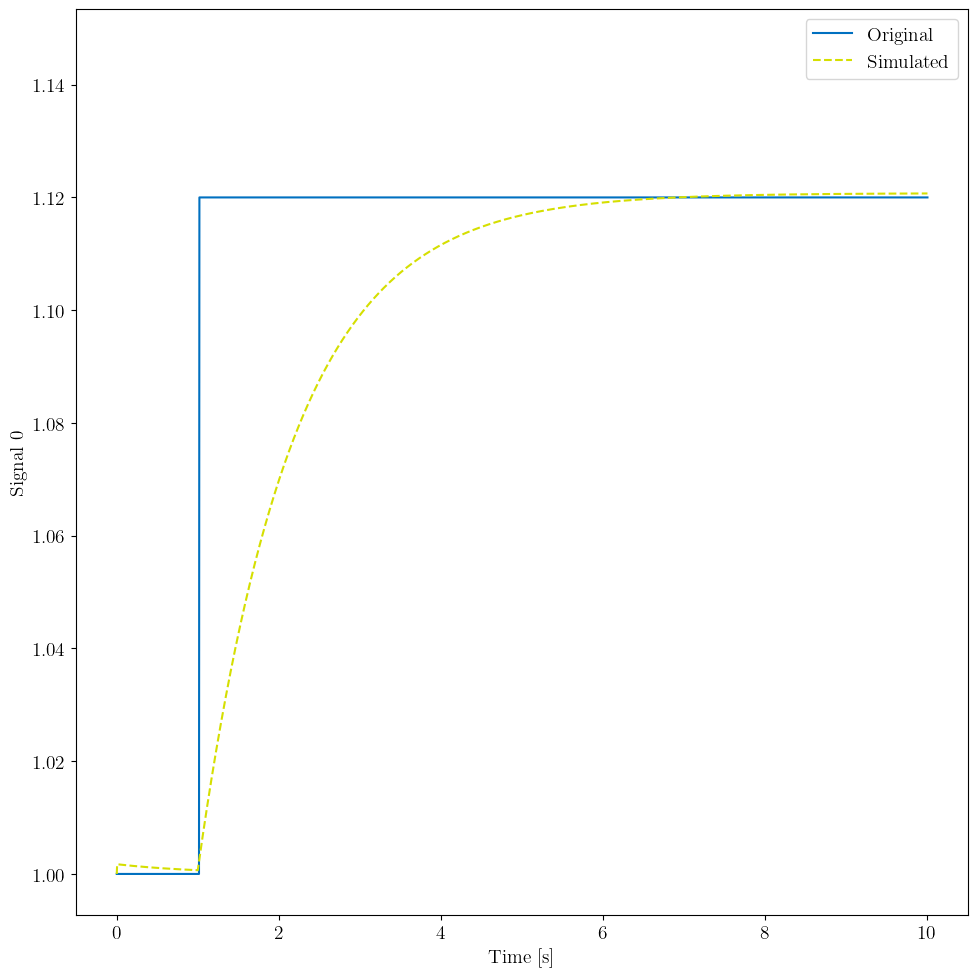

100%|██████████| 10/10 [01:01<00:00,  6.17s/it]

Optimization finished in 61.67 seconds


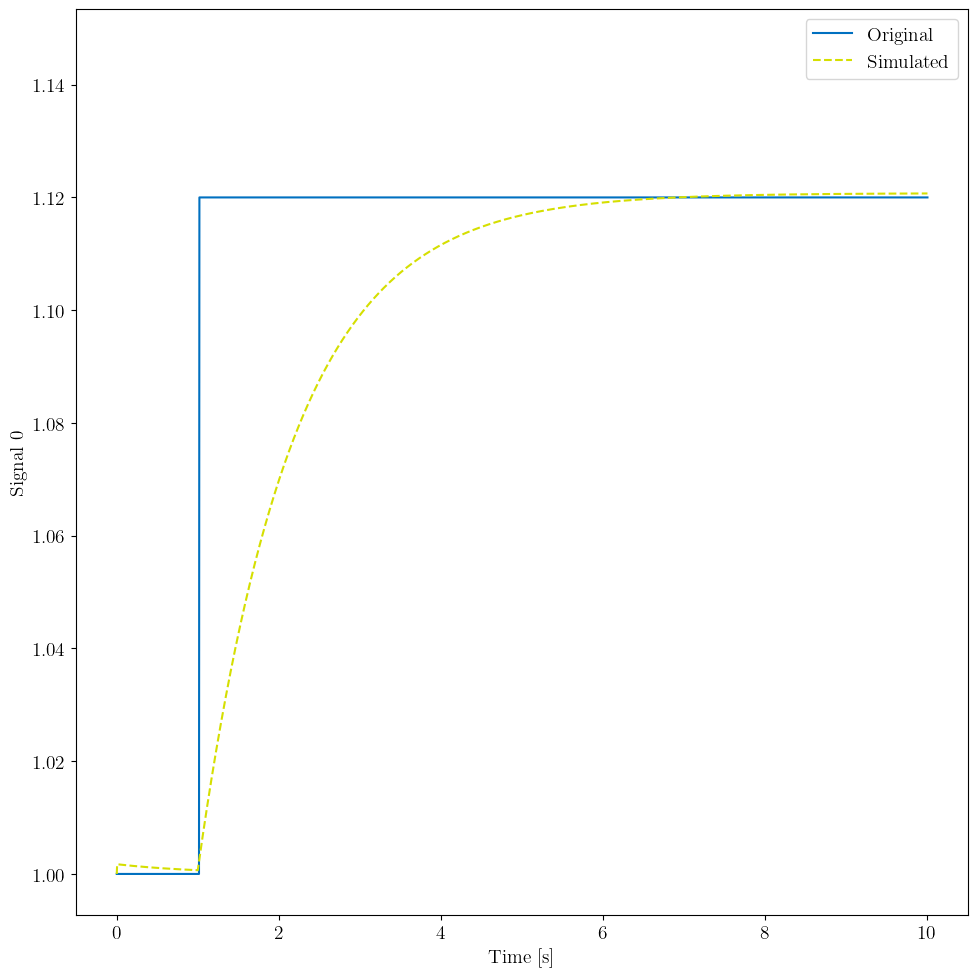

In [164]:
torch.autograd.set_detect_anomaly(True)  # Bessere Fehlermeldungen

result, opt_params, losses = opt.run(max_steps=10)

In [165]:
result

array([[1.        ],
       [1.00171844],
       [1.00171317],
       ...,
       [1.12070351],
       [1.12070374],
       [1.12070397]], shape=(2002, 1))

In [166]:
opt_params

{'Controller k_d': 0.6463627086606507, 'Controller k_i': 0.3607667543261625}

In [167]:
losses

[0.20614272008268347,
 0.17174410528864872,
 0.14891720591624266,
 0.12218894157801365,
 0.13108554979916962,
 0.12048543668184433,
 0.1192425236646243,
 0.11864703817557043,
 0.1179959256198308,
 0.11272507277014951]

In [168]:
import yaml

# generate output directory and file
output_dir = os.path.join(
    os.getcwd(),
    "data",
    # "optimization_results"
)
os.makedirs(output_dir, exist_ok=True)
output_file = os.path.join(output_dir, "optimization_data.yaml")

# open output_file
with open(output_file, "a") as f:
    # save result, opt_params, min_loss to file in yaml format
    data = {
        f"iteration {v_ref}": {
            "v_ref": float(v_ref),
            "optimized_parameters": opt_params,
            "minimum_loss": losses,
            # "optimization_result": result
        }
    }
    # save outputs to file
    yaml.dump(data, f)